In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

In [5]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 150, "axes.titlesize": 13,
                     "axes.labelsize": 11, "xtick.labelsize": 9,
                     "ytick.labelsize": 9})

ALPHA      = 0.05


In [6]:
print("STEP 1 – DATA LOADING")

STEP 1 – DATA LOADING


In [8]:
# PM2.5 (World Bank)
df_pm25 = pd.read_csv(
    "/content/2f46c15c-49bc-4ef9-807f-78b4b0075a28_Data.csv"
)[["Country Name", "Country Code", "2020 [YR2020]"]].copy()
df_pm25.columns = ["Country", "Code", "PM25"]
# World Bank marks missing values as ".." – convert those to NaN
df_pm25["PM25"] = pd.to_numeric(df_pm25["PM25"], errors="coerce")
print(f"PM2.5  : {df_pm25['PM25'].notna().sum()} valid rows (of {len(df_pm25)} total)")


PM2.5  : 200 valid rows (of 222 total)


In [9]:
#  Life Expectancy (Our World in Data)
df_le_raw = pd.read_csv("/content/life-expectancy-hmd-unwpp.csv")
df_le = df_le_raw[df_le_raw["Year"] == 2020][
    ["Entity", "Life expectancy - Sex: total - Age: 0 - Type: period"]
].copy()
df_le.columns = ["Country", "LifeExpectancy"]
print(f"Life Exp: {len(df_le)} rows for 2020")


Life Exp: 201 rows for 2020


In [10]:
# HDI (Our World in Data)
df_hdi_raw = pd.read_csv("/content/human-development-index.csv")
df_hdi = df_hdi_raw[df_hdi_raw["Year"] == 2020][
    ["Entity", "Code", "Human Development Index", "World region according to OWID"]
].copy()
df_hdi.columns = ["Country", "Code", "HDI", "Region"]
print(f"HDI     : {len(df_hdi)} rows for 2020")

HDI     : 192 rows for 2020


In [11]:
print("STEP 2 – MERGING DATASETS")

STEP 2 – MERGING DATASETS


In [12]:
# Inner-join all three datasets on country name
df = pd.merge(df_pm25[["Country", "PM25"]], df_le, on="Country", how="inner")
df = pd.merge(df, df_hdi[["Country", "HDI", "Region"]], on="Country", how="inner")
df.dropna(subset=["PM25", "LifeExpectancy", "HDI"], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Countries after full inner merge: {len(df)}")
print(df[["Country", "PM25", "LifeExpectancy", "HDI", "Region"]].head(10).to_string(index=False))

Countries after full inner merge: 166
            Country      PM25  LifeExpectancy   HDI        Region
        Afghanistan 46.087094         61.4537 0.501          Asia
            Albania 15.707004         77.8241 0.794        Europe
            Algeria 25.552656         73.2568 0.742        Africa
            Andorra  9.080281         79.4177 0.851        Europe
             Angola 25.145238         63.1164 0.610        Africa
Antigua and Barbuda 19.698270         77.1613 0.840 North America
          Argentina 14.908174         75.8781 0.851 South America
            Armenia 30.579633         68.8898 0.761          Asia
          Australia  8.251717         83.6639 0.950       Oceania
            Austria 10.933514         81.8037 0.925        Europe


In [13]:
print("STEP 3 – EXPLORATORY DATA ANALYSIS")

STEP 3 – EXPLORATORY DATA ANALYSIS


In [53]:
# 3a. Descriptive statistics
desc = df[["PM25", "LifeExpectancy", "HDI"]].describe().T
desc["skewness"] = df[["PM25", "LifeExpectancy", "HDI"]].skew()
desc["kurtosis"] = df[["PM25", "LifeExpectancy", "HDI"]].kurtosis()
print("\nDescriptive Statistics:")
print(desc.round(3).to_string())

# 3b. Missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3c. IQR outlier detection
def iqr_outliers(series, label):
    """Print IQR outlier summary and return outlier rows."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    lo, hi = Q1 - 1.5 * (Q3 - Q1), Q3 + 1.5 * (Q3 - Q1)
    mask   = (series < lo) | (series > hi)
    print(f"\n{label} – IQR outliers ({mask.sum()} found)  Fences: [{lo:.2f}, {hi:.2f}]")
    return df.loc[mask, ["Country", label]].sort_values(label, ascending=False)

print(iqr_outliers(df["PM25"],          "PM25").to_string(index=False))
print(iqr_outliers(df["LifeExpectancy"],"LifeExpectancy").to_string(index=False))

# 3d. HDI group assignment (UNDP standard thresholds)
def hdi_category(h):
    if   h < 0.55: return "Low (<0.55)"
    elif h < 0.70: return "Medium (0.55-0.70)"
    elif h < 0.80: return "High (0.70-0.80)"
    else:          return "Very High (>=0.80)"

df["HDI_Group"] = df["HDI"].apply(hdi_category)
GROUP_ORDER = ["Low (<0.55)", "Medium (0.55-0.70)", "High (0.70-0.80)", "Very High (>=0.80)"]
GROUP_COLORS = {"Low (<0.55)": "#e74c3c", "Medium (0.55-0.70)": "#f39c12",
                "High (0.70-0.80)": "#2ecc71", "Very High (>=0.80)": "#2980b9"}

print("\nCountries per HDI group:")
print(df["HDI_Group"].value_counts().reindex(GROUP_ORDER).to_string())


Descriptive Statistics:
                count    mean     std     min     25%     50%     75%     max  skewness  kurtosis
PM25            166.0  24.028  15.370   4.895  12.602  20.011  30.698  85.122     1.333     1.745
LifeExpectancy  166.0  71.741   7.582  50.596  66.370  72.261  77.722  84.670    -0.328    -0.591
HDI             166.0   0.730   0.152   0.386   0.611   0.744   0.852   0.969    -0.358    -0.822

Missing values per column:
Country           0
PM25              0
LifeExpectancy    0
HDI               0
Region            0
HDI_Group         0
PM25_Cat          0
dtype: int64

PM25 – IQR outliers (6 found)  Fences: [-14.54, 57.84]
     Country      PM25
       Niger 85.122346
       Qatar 75.663033
  Mauritania 70.822444
     Senegal 63.740221
     Bahrain 58.495063
Burkina Faso 58.470676

LifeExpectancy – IQR outliers (0 found)  Fences: [49.34, 94.75]
Empty DataFrame
Columns: [Country, LifeExpectancy]
Index: []

Countries per HDI group:
HDI_Group
Low (<0.55)           2

In [28]:
WHO_THRESHOLD = 15.0 # World Health Organization's threshold for polluted air by PM2.5
df["PM25_Cat"] = np.where(df["PM25"] <= WHO_THRESHOLD, "Low PM2.5 (<=15)", "High PM2.5 (>15)")

print("\nCountries per HDI group:")
print(df["HDI_Group"].value_counts().reindex(GROUP_ORDER).to_string())

print("\nCountries per PM2.5 category (WHO 15 µg/m³ threshold):")
print(df["PM25_Cat"].value_counts().to_string())

# Pre-build all group arrays here so they are available in every subsequent
# cell regardless of execution order in Colab
groups_le       = [df[df["HDI_Group"] == g]["LifeExpectancy"].dropna().values
                   for g in GROUP_ORDER]
low_pm25        = df[df["PM25_Cat"] == "Low PM2.5 (<=15)"]["LifeExpectancy"]
high_pm25       = df[df["PM25_Cat"] == "High PM2.5 (>15)"]["LifeExpectancy"]
le_low_hdi      = df[df["HDI_Group"] == "Low (<0.55)"]["LifeExpectancy"]
le_veryhigh_hdi = df[df["HDI_Group"] == "Very High (>=0.80)"]["LifeExpectancy"]



Countries per HDI group:
HDI_Group
Low (<0.55)           24
Medium (0.55-0.70)    40
High (0.70-0.80)      42
Very High (>=0.80)    60

Countries per PM2.5 category (WHO 15 µg/m³ threshold):
PM25_Cat
High PM2.5 (>15)    105
Low PM2.5 (<=15)     61


In [29]:
print("STEP 4 – VISUALISATIONS")

STEP 4 – VISUALISATIONS


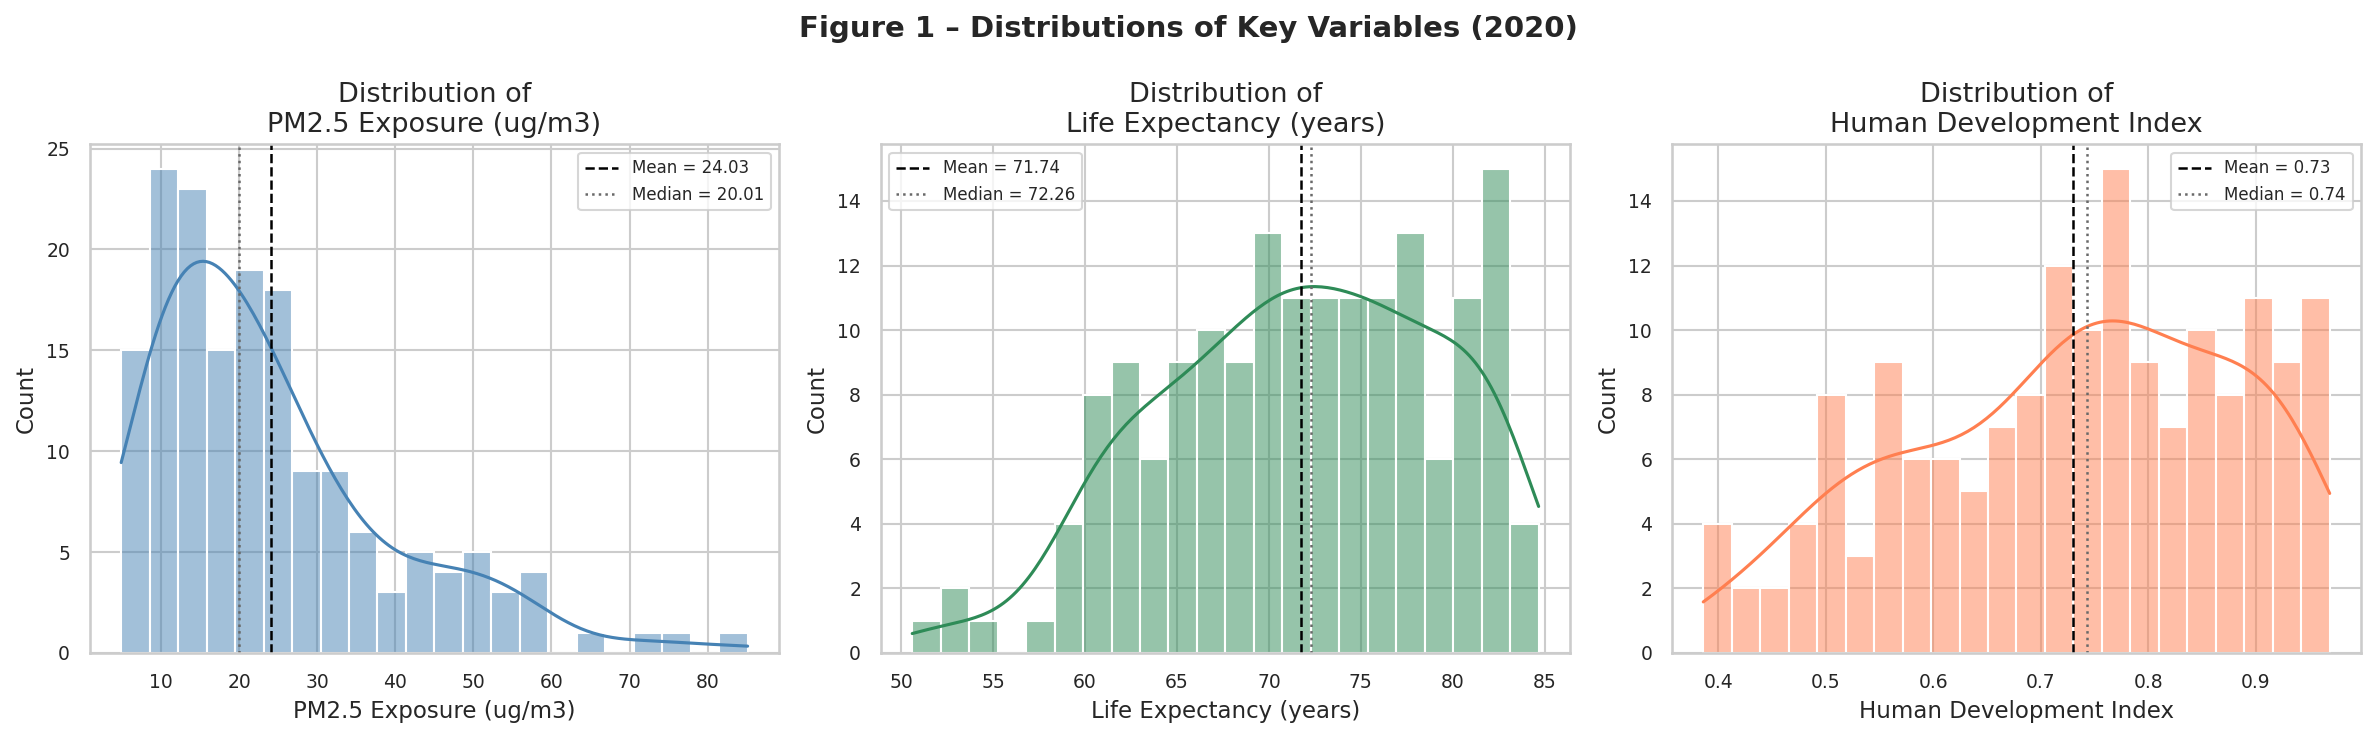

In [30]:
# Figure 1: Distributions
fig1, axes = plt.subplots(1, 3, figsize=(16, 5))
fig1.suptitle("Figure 1 – Distributions of Key Variables (2020)",
              fontsize=14, fontweight="bold")

for ax, (col, xlabel, color) in zip(axes, [
    ("PM25",          "PM2.5 Exposure (ug/m3)",  "steelblue"),
    ("LifeExpectancy","Life Expectancy (years)",  "seagreen"),
    ("HDI",           "Human Development Index", "coral"),
]):
    sns.histplot(df[col], kde=True, color=color, bins=22, edgecolor="white", ax=ax)
    ax.axvline(df[col].mean(),   color="black",   ls="--", lw=1.2,
               label=f"Mean = {df[col].mean():.2f}")
    ax.axvline(df[col].median(), color="dimgray", ls=":",  lw=1.2,
               label=f"Median = {df[col].median():.2f}")
    ax.set_title(f"Distribution of\n{xlabel}")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()




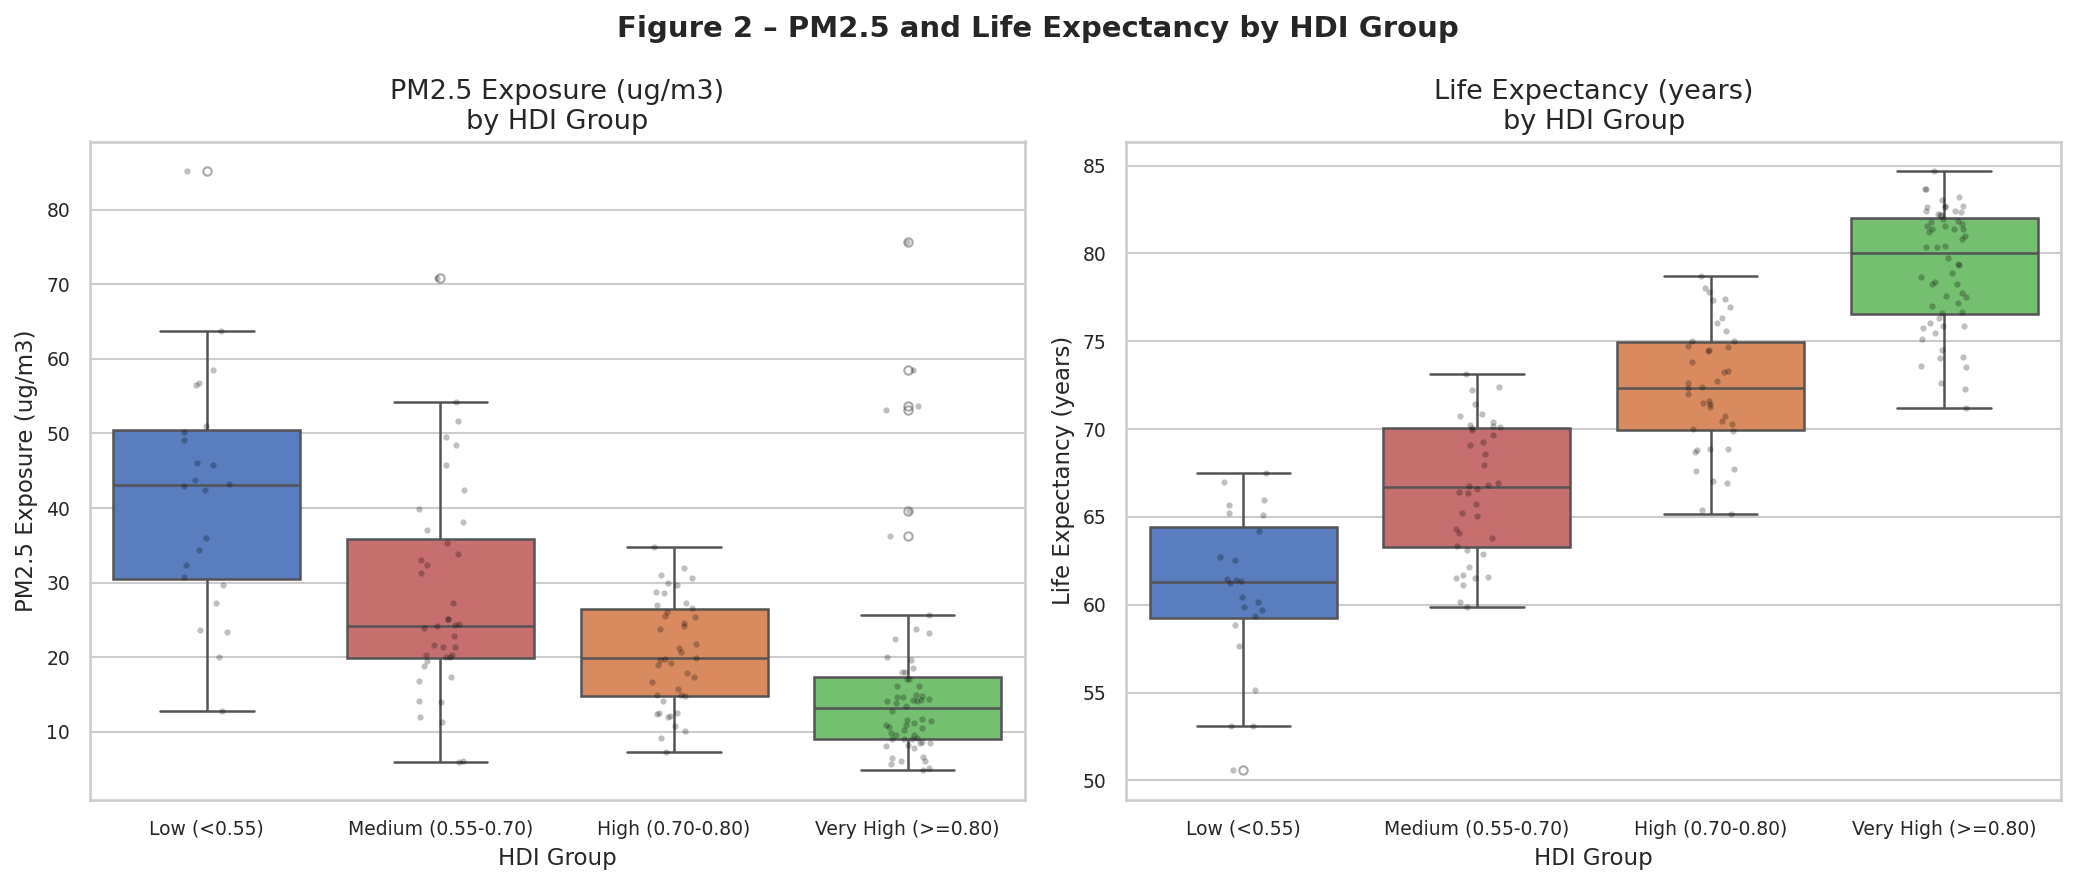

In [31]:
# Figure 2: Box plots by HDI group
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle("Figure 2 – PM2.5 and Life Expectancy by HDI Group",
              fontsize=14, fontweight="bold")

for ax, (col, ylabel) in zip(axes2, [
    ("PM25",          "PM2.5 Exposure (ug/m3)"),
    ("LifeExpectancy","Life Expectancy (years)"),
]):
    sns.boxplot(data=df, x="HDI_Group", y=col, order=GROUP_ORDER,
                hue="HDI_Group", ax=ax, linewidth=1.2, legend=False,
                flierprops=dict(marker="o", markersize=4, alpha=0.5))
    sns.stripplot(data=df, x="HDI_Group", y=col, order=GROUP_ORDER,
                  color="black", alpha=0.25, size=3, jitter=True, ax=ax)
    ax.set_title(f"{ylabel}\nby HDI Group")
    ax.set_xlabel("HDI Group")
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.show()

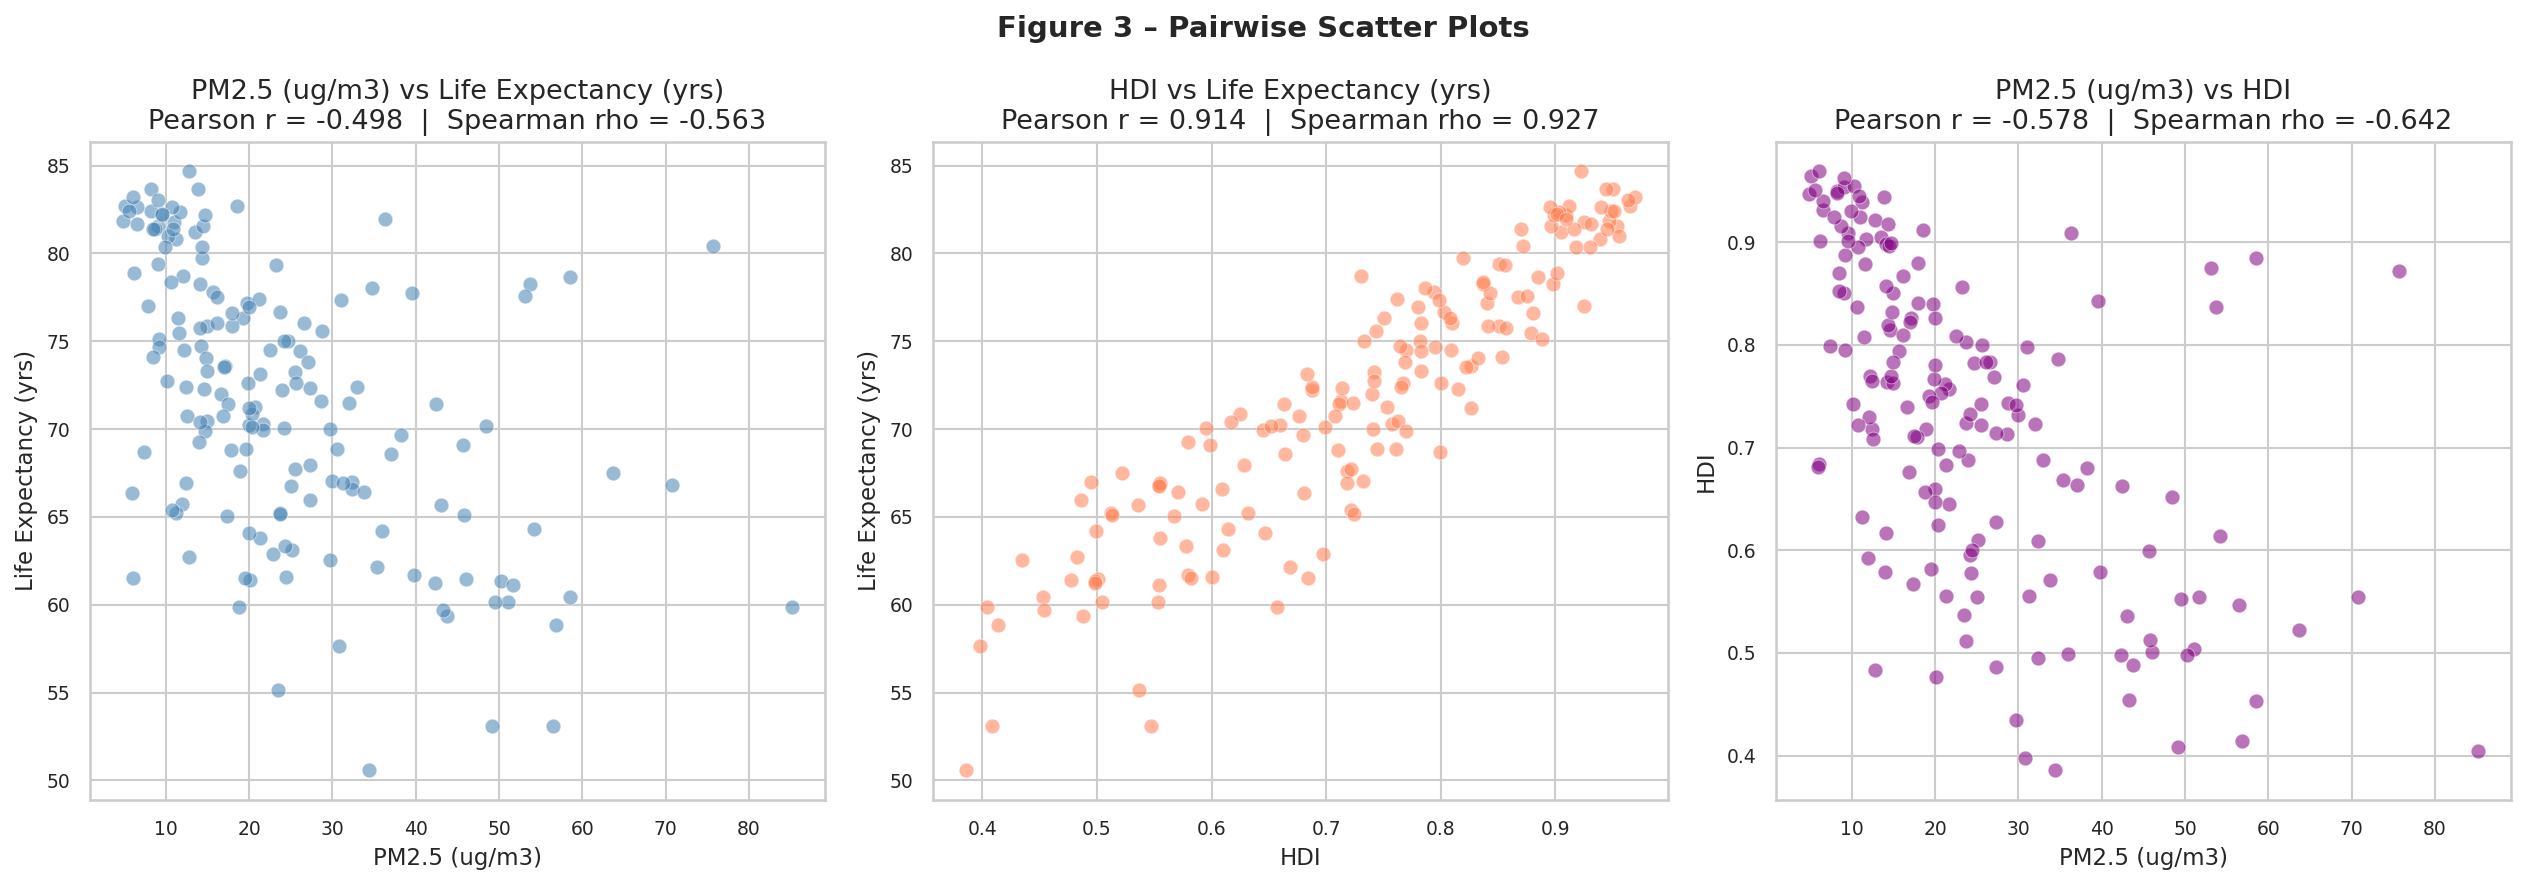

In [32]:
fig3, axes3 = plt.subplots(1, 3, figsize=(17, 6))
fig3.suptitle("Figure 3 – Pairwise Scatter Plots", fontsize=14, fontweight="bold")

for ax, (x, y, xl, yl, color) in zip(axes3, [
    ("PM25","LifeExpectancy","PM2.5 (ug/m3)", "Life Expectancy (yrs)","steelblue"),
    ("HDI", "LifeExpectancy","HDI",           "Life Expectancy (yrs)","coral"),
    ("PM25","HDI",           "PM2.5 (ug/m3)", "HDI",                  "purple"),
]):
    ax.scatter(df[x], df[y], alpha=0.55, color=color,
               edgecolors="white", linewidths=0.4, s=50)
    r_p, _ = stats.pearsonr(df[x], df[y])
    r_s, _ = stats.spearmanr(df[x], df[y])
    ax.set_title(f"{xl} vs {yl}\nPearson r = {r_p:.3f}  |  Spearman rho = {r_s:.3f}")
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)

plt.tight_layout()
plt.show()


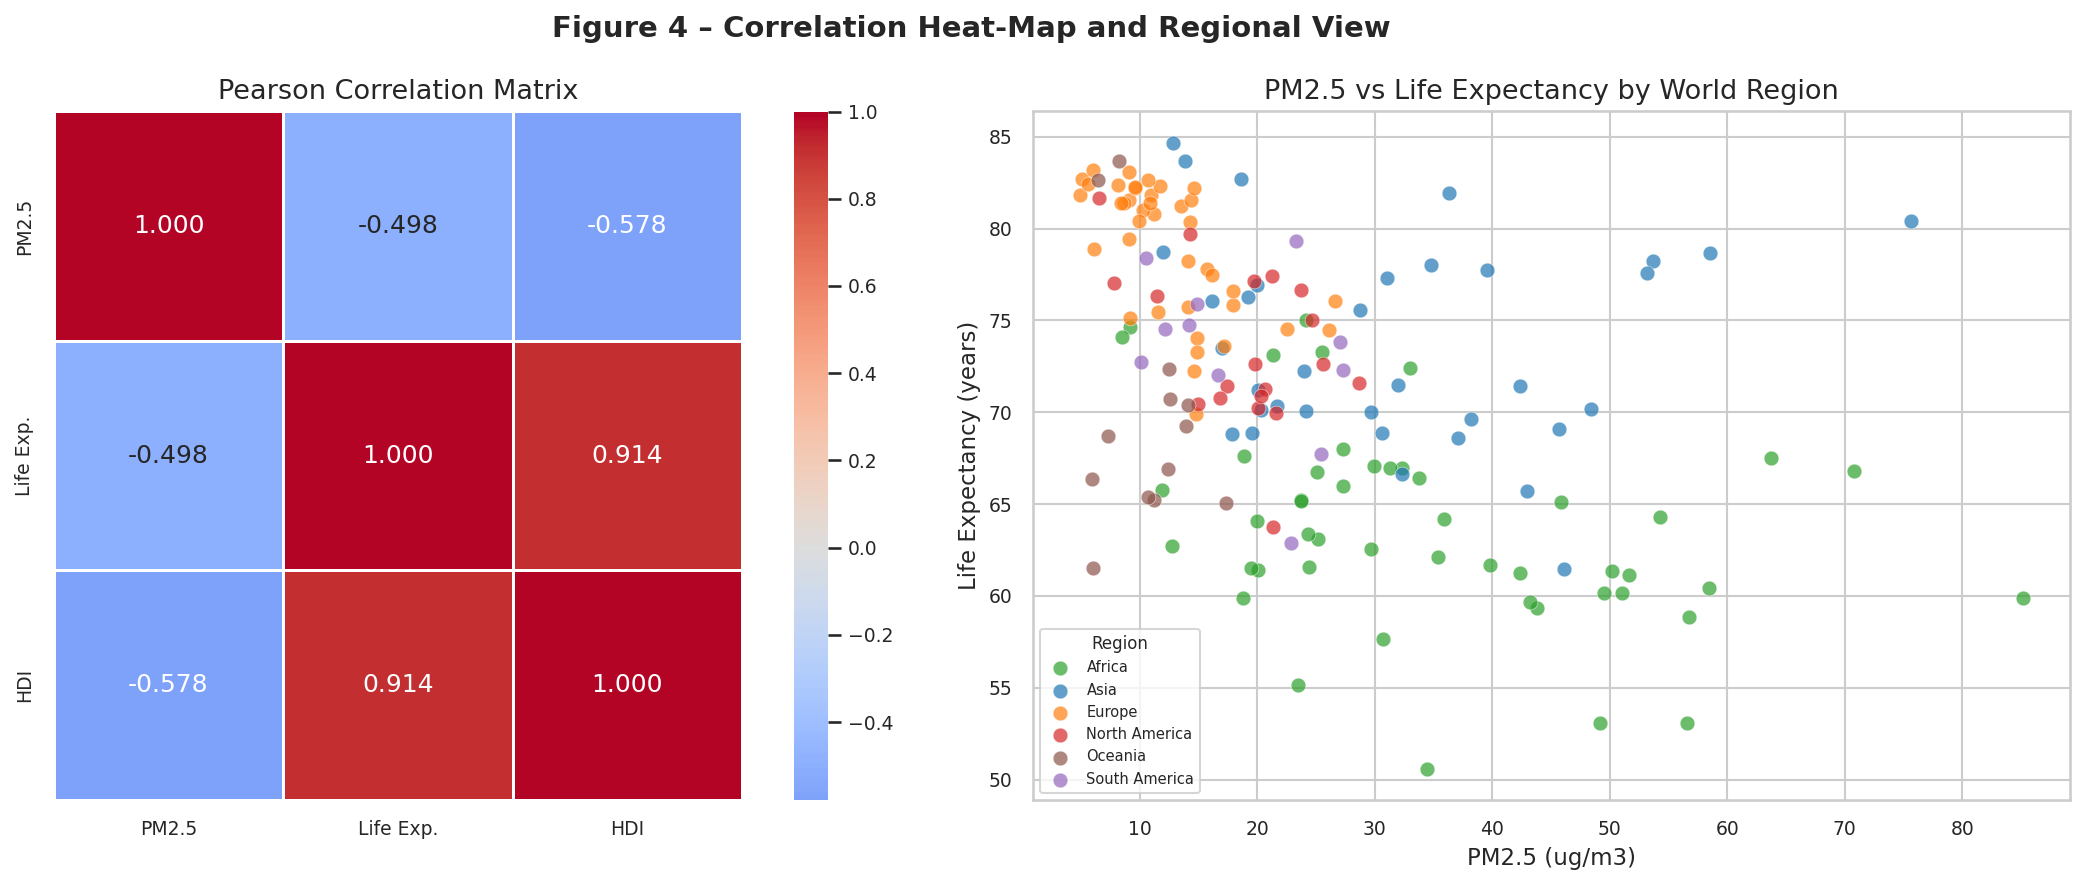

In [33]:
fig4, axes4 = plt.subplots(1, 2, figsize=(15, 6))
fig4.suptitle("Figure 4 – Correlation Heat-Map and Regional View",
              fontsize=14, fontweight="bold")

corr = df[["PM25", "LifeExpectancy", "HDI"]].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0,
            ax=axes4[0], square=True, linewidths=0.6,
            xticklabels=["PM2.5", "Life Exp.", "HDI"],
            yticklabels=["PM2.5", "Life Exp.", "HDI"])
axes4[0].set_title("Pearson Correlation Matrix")

region_palette = dict(zip(df["Region"].dropna().unique(),
                          sns.color_palette("tab10", n_colors=df["Region"].nunique())))
for region, grp in df.groupby("Region"):
    axes4[1].scatter(grp["PM25"], grp["LifeExpectancy"],
                     label=region, color=region_palette.get(region, "grey"),
                     alpha=0.70, s=50, edgecolors="white", linewidths=0.3)
axes4[1].set_title("PM2.5 vs Life Expectancy by World Region")
axes4[1].set_xlabel("PM2.5 (ug/m3)")
axes4[1].set_ylabel("Life Expectancy (years)")
axes4[1].legend(fontsize=7, title="Region", title_fontsize=8)

plt.tight_layout()
plt.show()

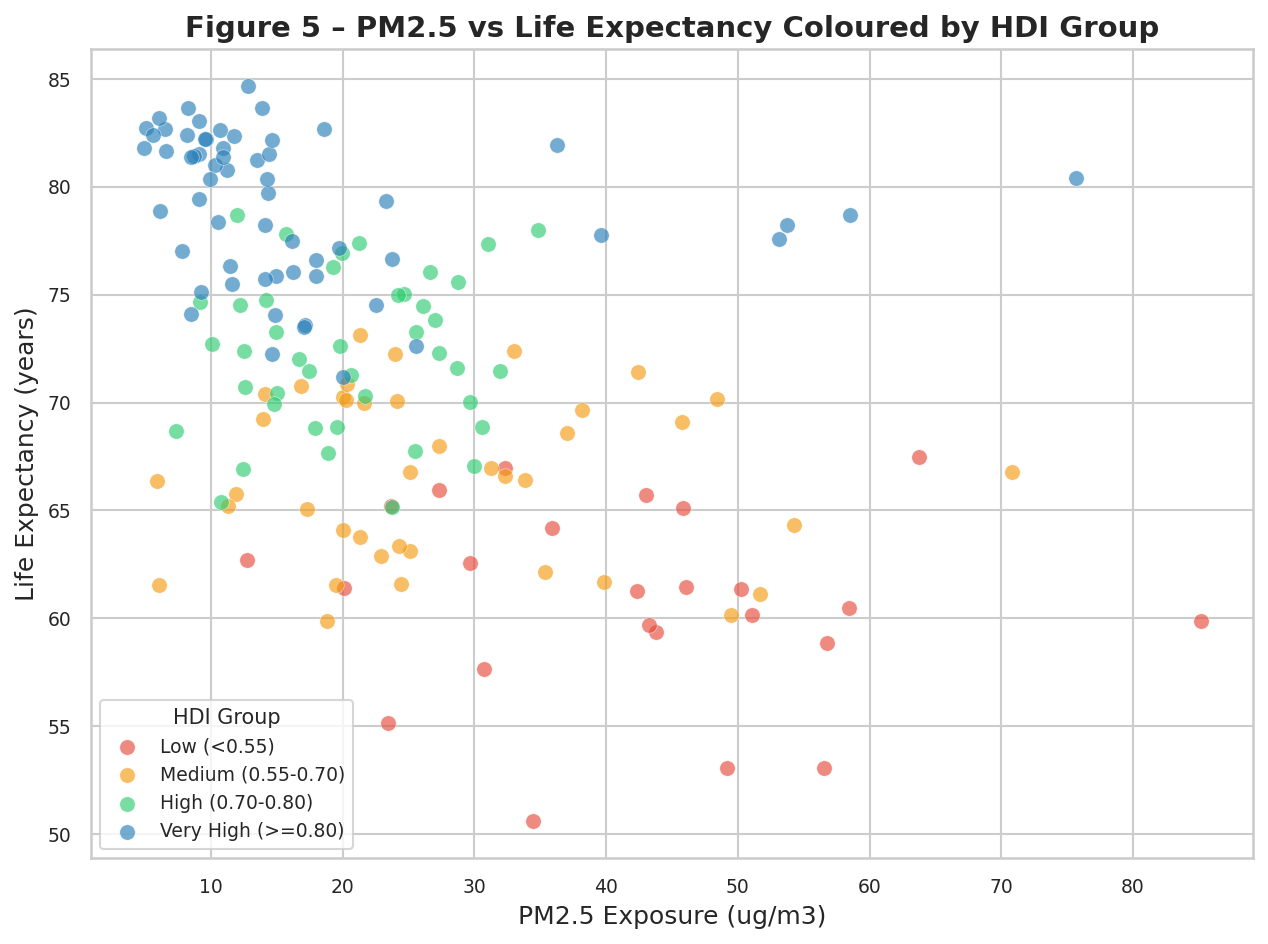

In [34]:
#  Figure 5: PM2.5 vs Life Expectancy coloured by HDI group
fig5, ax5 = plt.subplots(figsize=(10, 7))
for grp in GROUP_ORDER:
    sub = df[df["HDI_Group"] == grp]
    ax5.scatter(sub["PM25"], sub["LifeExpectancy"],
                color=GROUP_COLORS[grp], alpha=0.65, s=55,
                edgecolors="white", linewidths=0.3, label=grp)
ax5.set_title("Figure 5 – PM2.5 vs Life Expectancy Coloured by HDI Group",
              fontsize=14, fontweight="bold")
ax5.set_xlabel("PM2.5 Exposure (ug/m3)", fontsize=12)
ax5.set_ylabel("Life Expectancy (years)", fontsize=12)
ax5.legend(title="HDI Group", fontsize=9, title_fontsize=10)
plt.show()

In [21]:
print("STEP 5 – HYPOTHESIS TESTING")
print("HO : HDI does not buffer the effects of PM2.5 exposure")
print("H1 : HDI buffers the effects of PM2.5 exposure")

STEP 5 – HYPOTHESIS TESTING
HO : HDI does not buffer the effects of PM2.5 exposure
H1 : HDI buffers the effects of PM2.5 exposure


In [50]:
print("\n--- H1: One-way ANOVA – Life Expectancy across HDI Groups ---")
print("  H0: Mean LE is equal across all four HDI groups")
print("  H1: At least one group mean differs\n")

f_stat, f_p = stats.f_oneway(*groups_le)
print(f"  One-way ANOVA: F = {f_stat:.4f},  p = {f_p:.4e}")
decision_h1 = "REJECT H0" if f_p < ALPHA else "FAIL TO REJECT H0"
print(f"  Decision: {decision_h1} at alpha={ALPHA}")

# Group means for context
print("\n  Group means:")
for g in GROUP_ORDER:
    m = df[df["HDI_Group"] == g]["LifeExpectancy"].mean()
    print(f"    {g:25s}: {m:.2f} years")

# Post-hoc: all pairwise two-sample t-tests with Bonferroni correction
if f_p < ALPHA:
    pairs  = [(i, j) for i in range(len(GROUP_ORDER))
                     for j in range(i + 1, len(GROUP_ORDER))]
    bonf   = ALPHA / len(pairs)
    print(f"\n  Post-hoc pairwise t-tests (Bonferroni alpha = {bonf:.4f}):")
    print(f"  {'Group A':25s} {'Group B':25s} {'t-stat':>9} {'p-value':>12} {'Sig?':>5}")

    for i, j in pairs:
        t, p_t = stats.ttest_ind(groups_le[i], groups_le[j], equal_var=True)
        print(f"  {GROUP_ORDER[i]:25s} {GROUP_ORDER[j]:25s} "
              f"{t:>9.4f} {p_t:>12.4e} {'Yes' if p_t < bonf else 'No':>5}")


--- H1: One-way ANOVA – Life Expectancy across HDI Groups ---
  H0: Mean LE is equal across all four HDI groups
  H1: At least one group mean differs

  One-way ANOVA: F = 173.9901,  p = 1.9210e-50
  Decision: REJECT H0 at alpha=0.05

  Group means:
    Low (<0.55)              : 60.81 years
    Medium (0.55-0.70)       : 66.58 years
    High (0.70-0.80)         : 72.32 years
    Very High (>=0.80)       : 79.15 years

  Post-hoc pairwise t-tests (Bonferroni alpha = 0.0083):
  Group A                   Group B                      t-stat      p-value  Sig?
  Low (<0.55)               Medium (0.55-0.70)          -5.4759   8.3790e-07   Yes
  Low (<0.55)               High (0.70-0.80)           -11.4164   4.4148e-17   Yes
  Low (<0.55)               Very High (>=0.80)         -20.2951   1.0225e-33   Yes
  Medium (0.55-0.70)        High (0.70-0.80)            -7.0024   7.0197e-10   Yes
  Medium (0.55-0.70)        Very High (>=0.80)         -17.2131   2.1919e-31   Yes
  High (0.70-0.80)   

In [36]:
print("\n--- H2: Two-sample t-test – LE: Low PM2.5 vs High PM2.5 countries ---")
print("  H0: Mean Life Expectation is equal between Low and High PM2.5 groups")
print("  H1: Mean Life Expectation is higher in Low PM2.5 countries (one-tailed)\n")

print(f"  Low  PM2.5 (<=15 µg/m³): n={len(low_pm25)}, mean LE = {low_pm25.mean():.2f} yrs")
print(f"  High PM2.5 (>15  µg/m³): n={len(high_pm25)}, mean LE = {high_pm25.mean():.2f} yrs")

t2, p2_twotail = stats.ttest_ind(low_pm25, high_pm25)
p2_onetail = p2_twotail / 2  # one-tailed p (direction confirmed by means)
print(f"\n  Two-sample t-test:")
print(f"  t = {t2:.4f},  p (two-tailed) = {p2_twotail:.4e},  p (one-tailed) = {p2_onetail:.4e}")
decision_h2 = "REJECT H0" if p2_onetail < ALPHA else "FAIL TO REJECT H0"
print(f"  Decision (one-tailed): {decision_h2} at alpha={ALPHA}")


--- H2: Two-sample t-test – LE: Low PM2.5 vs High PM2.5 countries ---
  H0: Mean LE is equal between Low and High PM2.5 groups
  H1: Mean LE is higher in Low PM2.5 countries (one-tailed)

  Low  PM2.5 (<=15 µg/m³): n=61, mean LE = 76.74 yrs
  High PM2.5 (>15  µg/m³): n=105, mean LE = 68.84 yrs

  Two-sample t-test:
  t = 7.4775,  p (two-tailed) = 4.3300e-12,  p (one-tailed) = 2.1650e-12
  Decision (one-tailed): REJECT H0 at alpha=0.05


In [52]:
print("\nH3: Two-sample t-test – LE: Low HDI vs Very High HDI ")
print("  H0: Mean Life Expectation is equal for Low HDI and Very High HDI countries")
print("  H1: Mean Life Expectation differs between the two extreme groups (two-tailed)\n")

print(f"  Low HDI       (< 0.55): n={len(le_low_hdi)}, mean LE = {le_low_hdi.mean():.2f} yrs")
print(f"  Very High HDI (>=0.80): n={len(le_veryhigh_hdi)}, mean LE = {le_veryhigh_hdi.mean():.2f} yrs")

t3, p3 = stats.ttest_ind(le_low_hdi, le_veryhigh_hdi)
print(f"\n  Two-sample t-test:")
print(f"  t = {t3:.4f},  p = {p3:.4e}")
decision_h3 = "REJECT H0" if p3 < ALPHA else "FAIL TO REJECT H0"
print(f"  Decision: {decision_h3} at alpha={ALPHA}")



H3: Two-sample t-test – LE: Low HDI vs Very High HDI 
  H0: Mean Life Expectation is equal for Low HDI and Very High HDI countries
  H1: Mean Life Expectation differs between the two extreme groups (two-tailed)

  Low HDI       (< 0.55): n=24, mean LE = 60.81 yrs
  Very High HDI (>=0.80): n=60, mean LE = 79.15 yrs

  Two-sample t-test:
  t = -20.2951,  p = 1.0225e-33
  Decision: REJECT H0 at alpha=0.05


In [51]:
print("\nH4: Chi-square Test – PM2.5 Category vs HDI Group")
print("  H0: PM2.5 category and HDI tier are independent")
print("  H1: PM2.5 category and HDI tier are associated\n")

# Contingency table
ct = pd.crosstab(df["HDI_Group"], df["PM25_Cat"])
ct = ct.reindex(GROUP_ORDER)
ct.index.name   = "HDI_Group"
ct.columns.name = "PM25_Category"
print("Contingency table (observed counts):")
print(ct.to_string())

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print(f"\n  Chi-square statistic = {chi2:.4f}")
print(f"  Degrees of freedom   = {dof}")
print(f"  p-value              = {p_chi:.4e}")

# Check expected frequency assumption (all cells >= 5)
min_expected = expected.min()
print(f"  Min expected frequency = {min_expected:.2f} "
      f"({'OK' if min_expected >= 5 else 'WARNING: some cells < 5'})")

decision_h4 = "REJECT H0" if p_chi < ALPHA else "FAIL TO REJECT H0"
print(f"\n  Decision: {decision_h4} at alpha={ALPHA}")

print("\n  Expected frequencies (all should be >= 5 for valid chi-square):")
print("  Rows = HDI Group  |  Columns = PM2.5 Category")
exp_df = pd.DataFrame(expected, index=GROUP_ORDER, columns=ct.columns)
exp_df.index.name   = None
exp_df.columns.name = None
print(exp_df.round(2).to_string())


--- H4: Chi-square Test – PM2.5 Category vs HDI Group ---
  H0: PM2.5 category and HDI tier are independent
  H1: PM2.5 category and HDI tier are associated

Contingency table (observed counts):
PM25_Category       High PM2.5 (>15)  Low PM2.5 (<=15)
HDI_Group                                             
Low (<0.55)                       23                 1
Medium (0.55-0.70)                34                 6
High (0.70-0.80)                  29                13
Very High (>=0.80)                19                41

  Chi-square statistic = 45.4598
  Degrees of freedom   = 3
  p-value              = 7.3883e-10
  Min expected frequency = 8.82 (OK)

  Decision: REJECT H0 at alpha=0.05

  Expected frequencies (all should be >= 5 for valid chi-square):
  Rows = HDI Group  |  Columns = PM2.5 Category
                    High PM2.5 (>15)  Low PM2.5 (<=15)
Low (<0.55)                    15.18              8.82
Medium (0.55-0.70)             25.30             14.70
High (0.70-0.80)       